In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## Load Shear Profile Data

Read the output files from test_shear:
1. `shear_input.info` - Original prescribed shear profile
2. `baseflow.dat` - Computed baseflow quantities from CALC_BOUSSI_BASEFLOW

In [2]:
## Load Shear Profile Data

# Read input shear profile
try:
    shear_input = np.loadtxt('../../output/shear_input.info')
    r_shear = shear_input[:, 0]
    shear_orig = shear_input[:, 1]
    print(f"Input shear profile loaded: {len(r_shear)} radial points")
    shear_available = True
except FileNotFoundError:
    print("Shear input file not found - skipping shear profile analysis")
    shear_available = False

# Read baseflow data (generated by CALC_BOUSSI_BASEFLOW)
try:
    baseflow = np.loadtxt('../../output/baseflow.dat')
    r_bf = baseflow[:, 0]
    rup0 = baseflow[:, 1]  # r*u_phi
    oz0 = baseflow[:, 2]   # omega_z
    omega0 = baseflow[:, 3] # angular velocity
    rd = baseflow[:, 4]     # Rayleigh discriminant
    
    print(f"Baseflow data loaded: {len(r_bf)} radial points")
    print(f"  r range: {r_bf[0]:.4f} to {r_bf[-1]:.4f}")
    baseflow_available = True
except FileNotFoundError:
    print("Baseflow file not found - skipping baseflow analysis")
    baseflow_available = False

if shear_available and baseflow_available:
    # Reconstruct shear from baseflow: shear = omega_z - 2*omega
    shear_recon = oz0 - 2.0 * omega0
    print(f"\nShear reconstruction complete")
    print(f"  Max |shear_orig|:  {np.max(np.abs(shear_orig)):.6e}")
    print(f"  Max |shear_recon|: {np.max(np.abs(shear_recon)):.6e}")


Input shear profile loaded: 408 radial points
Baseflow data loaded: 408 radial points
  r range: 0.0471 to 5435.7230

Shear reconstruction complete
  Max |shear_orig|:  1.999818e+00
  Max |shear_recon|: 1.999818e+00


## Baseflow Workflow Visualization

Shows the complete workflow from CALC_BOUSSI_BASEFLOW:
- (a) Original prescribed shear profile
- (b) Integrated angular velocity ω(r)
- (c) Axial vorticity ω_z = 2ω + shear
- (d) Azimuthal velocity r·u_φ = r²·ω
- (e) Rayleigh discriminant (stability check)
- (f) Shear validation: original vs reconstructed

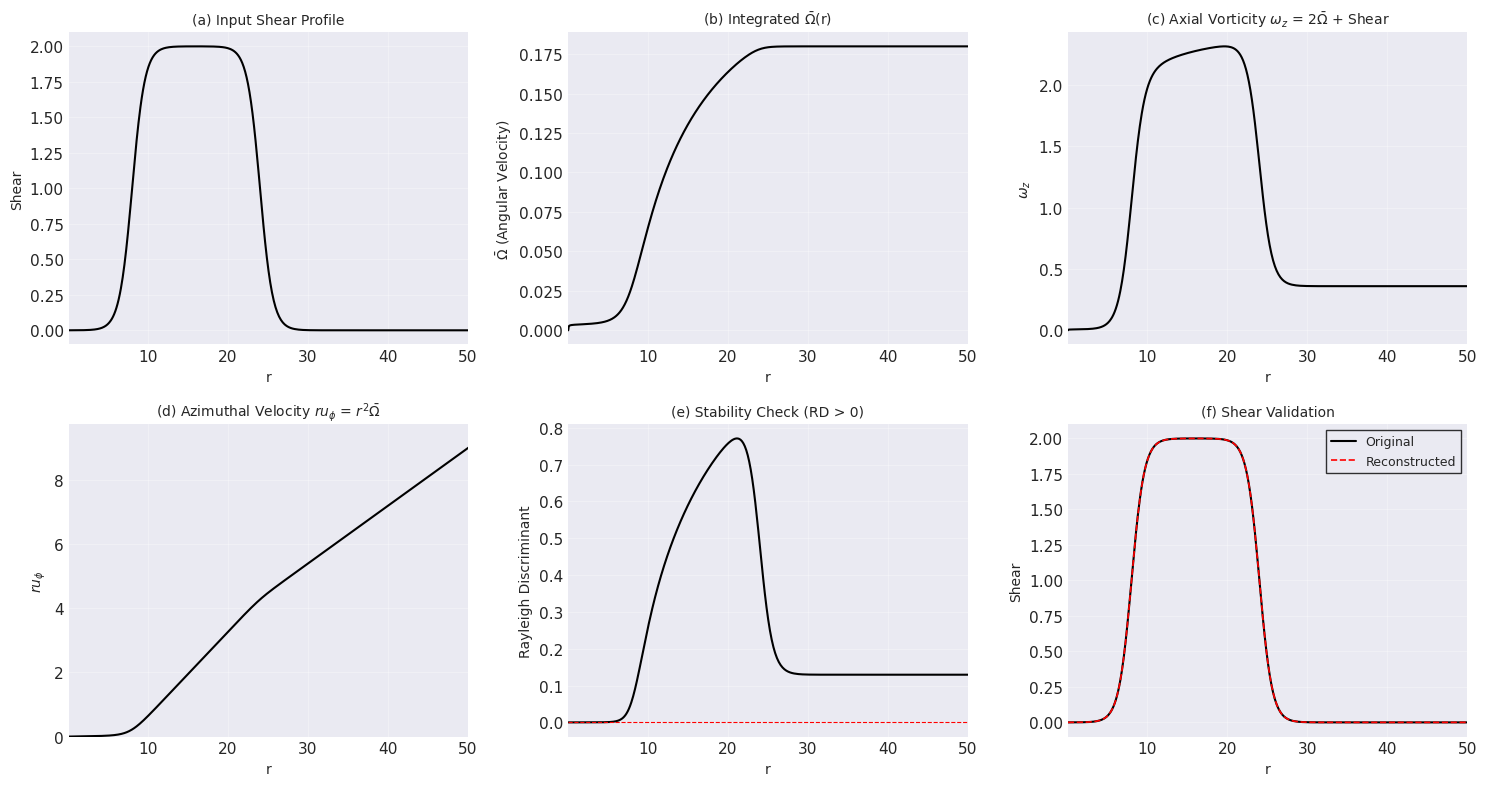

In [7]:
if shear_available and baseflow_available:

    r_max_plot = 50

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # Plot 1: Original shear profile
    axes[0,0].plot(r_shear, shear_orig, 'k-', linewidth=1.5)
    axes[0,0].set_xlabel('r', fontsize=10)
    axes[0,0].set_xlim([r_shear[0], r_max_plot])
    axes[0,0].set_ylabel('Shear', fontsize=10)
    axes[0,0].set_title('(a) Input Shear Profile', fontsize=10)
    axes[0,0].grid(True, alpha=0.3)
    
    # Plot 2: Angular velocity
    axes[0,1].plot(r_bf, omega0, 'k-', linewidth=1.5)
    axes[0,1].set_xlabel('r', fontsize=10)
    axes[0,1].set_xlim([r_bf[0], r_max_plot])
    axes[0,1].set_ylabel(r'$\bar{\Omega}$ (Angular Velocity)', fontsize=10)
    axes[0,1].set_title(r'(b) Integrated $\bar{\Omega}$(r)', fontsize=10)
    axes[0,1].grid(True, alpha=0.3)
    
    # Plot 3: Axial vorticity
    axes[0,2].plot(r_bf, oz0, 'k-', linewidth=1.5)
    axes[0,2].set_xlabel('r', fontsize=10)
    axes[0,2].set_xlim([r_bf[0], r_max_plot])
    axes[0,2].set_ylabel(r'$\omega_z$', fontsize=10)
    axes[0,2].set_title(r'(c) Axial Vorticity $\omega_z$ = 2$\bar{\Omega}$ + Shear', fontsize=10)
    axes[0,2].grid(True, alpha=0.3)
    
    # Plot 4: Azimuthal velocity
    axes[1,0].plot(r_bf, rup0, 'k-', linewidth=1.5)
    axes[1,0].set_xlabel('r', fontsize=10)
    axes[1,0].set_xlim([r_bf[0], r_max_plot])
    axes[1,0].set_ylabel(r'$r u_\phi$', fontsize=10)
    axes[1,0].set_ylim([0, np.max(rup0[0:np.where(r_bf<=r_max_plot)[0][-1]])*1.1])
    axes[1,0].set_title(r'(d) Azimuthal Velocity $r u_\phi$ = $r^2 \bar{\Omega}$', fontsize=10)
    axes[1,0].grid(True, alpha=0.3)
    
    # Plot 5: Rayleigh discriminant
    axes[1,1].plot(r_bf, rd, 'k-', linewidth=1.5)
    axes[1,1].axhline(y=0, color='r', linestyle='--', linewidth=0.8)
    axes[1,1].set_xlabel('r', fontsize=10)
    axes[1,1].set_xlim([r_bf[0], r_max_plot])
    axes[1,1].set_ylabel('Rayleigh Discriminant', fontsize=10)
    axes[1,1].set_title('(e) Stability Check (RD > 0)', fontsize=10)
    axes[1,1].grid(True, alpha=0.3)
    
    # Plot 6: Shear comparison
    axes[1,2].plot(r_shear, shear_orig, 'k-', linewidth=1.5, label='Original')
    axes[1,2].plot(r_bf, shear_recon, 'r--', linewidth=1.2, label='Reconstructed')
    axes[1,2].set_xlabel('r', fontsize=10)
    axes[1,2].set_xlim([r_shear[0], r_max_plot])
    axes[1,2].set_ylabel('Shear', fontsize=10)
    axes[1,2].set_title('(f) Shear Validation', fontsize=10)
    axes[1,2].legend(fontsize=9, frameon=True, fancybox=False, edgecolor='black')
    axes[1,2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Skipping baseflow workflow plot - data not available")

## Shear Reconstruction Error Analysis

Validates the accuracy of the CALC_BOUSSI_BASEFLOW workflow by comparing:
- Original prescribed shear
- Reconstructed shear = ω_z - 2ω (derived from baseflow)

In [4]:
if shear_available and baseflow_available:
    # Compute errors
    shear_abs_error = np.abs(shear_recon - shear_orig)
    shear_max = np.max(np.abs(shear_orig))
    shear_rms = np.sqrt(np.mean(shear_orig**2))
    
    # Normalized errors
    shear_norm_error = shear_abs_error / shear_max
    shear_norm_rms = np.sqrt(np.mean(shear_abs_error**2)) / shear_rms
    
    # Active region (where |shear| > 1% of max)
    shear_threshold = 0.01 * shear_max
    shear_active_mask = np.abs(shear_orig) > shear_threshold
    n_shear_active = np.sum(shear_active_mask)
    
    shear_active_abs_error = shear_abs_error[shear_active_mask]
    shear_active_rel_error = shear_active_abs_error / np.abs(shear_orig[shear_active_mask])
    
    print("=" * 60)
    print("SHEAR RECONSTRUCTION ERROR ANALYSIS")
    print("=" * 60)
    print(f"Shear amplitude: max|shear| = {shear_max:.6e}")
    print(f"Active region: {n_shear_active}/{len(shear_orig)} points with |shear| > {shear_threshold:.2e}")
    print()
    print("NORMALIZED ERRORS (Global):")
    print(f"  Max |error| / max|shear|  = {np.max(shear_norm_error):.6e}  ({100*np.max(shear_norm_error):.4f}%)")
    print(f"  RMS(error) / RMS(shear)   = {shear_norm_rms:.6e}  ({100*shear_norm_rms:.4f}%)")
    print()
    print("ACTIVE REGION STATISTICS (|shear| > 1% of max):")
    print(f"  Mean absolute error       = {np.mean(shear_active_abs_error):.6e}")
    print(f"  Max absolute error        = {np.max(shear_active_abs_error):.6e}")
    print(f"  Mean relative error       = {100*np.mean(shear_active_rel_error):.4f}%")
    print(f"  Max relative error        = {100*np.max(shear_active_rel_error):.4f}%")
    print()
    
    # Check stability
    rd_min = np.min(rd)
    print("STABILITY CHECK:")
    print(f"  Min(Rayleigh Discriminant) = {rd_min:.6e}")
    if rd_min > 0:
        print("  Status: STABLE (RD > 0 everywhere)")
    else:
        print("  Status: UNSTABLE (RD <= 0 detected)")
    
else:
    print("Skipping shear error analysis - data not available")

SHEAR RECONSTRUCTION ERROR ANALYSIS
Shear amplitude: max|shear| = 1.999818e+00
Active region: 204/408 points with |shear| > 2.00e-02

NORMALIZED ERRORS (Global):
  Max |error| / max|shear|  = 2.489791e-12  (0.0000%)
  RMS(error) / RMS(shear)   = 1.533856e-12  (0.0000%)

ACTIVE REGION STATISTICS (|shear| > 1% of max):
  Mean absolute error       = 1.724232e-12
  Max absolute error        = 4.979128e-12
  Mean relative error       = 0.0000%
  Max relative error        = 0.0000%

STABILITY CHECK:
  Min(Rayleigh Discriminant) = 1.926421e-12
  Status: STABLE (RD > 0 everywhere)


## Error Distribution Plots

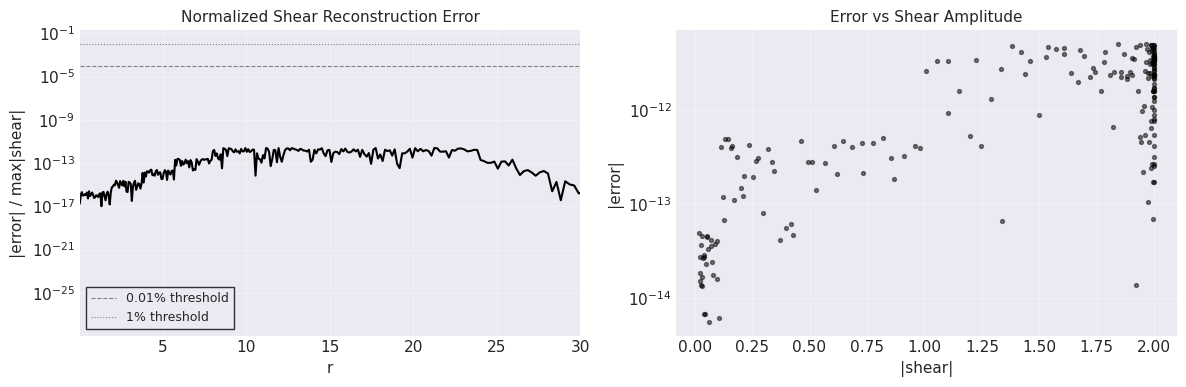

In [5]:
if shear_available and baseflow_available:
    # Plot error distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Left: Normalized error vs r
    ax1.semilogy(r_shear, shear_norm_error, 'k-', linewidth=1.5)
    ax1.axhline(y=1e-4, color='gray', linestyle='--', linewidth=0.8, label='0.01% threshold')
    ax1.axhline(y=1e-2, color='gray', linestyle=':', linewidth=0.8, label='1% threshold')
    ax1.set_xlabel('r', fontsize=11)
    ax1.set_xlim([r_shear[0], 30])
    ax1.set_ylabel('|error| / max|shear|', fontsize=11)
    ax1.set_title('Normalized Shear Reconstruction Error', fontsize=11)
    ax1.legend(fontsize=9, frameon=True, fancybox=False, edgecolor='black')
    ax1.grid(True, alpha=0.3)
    
    # Right: Error vs shear amplitude
    ax2.scatter(np.abs(shear_orig[shear_active_mask]), shear_active_abs_error, c='k', s=8, alpha=0.5)
    ax2.set_xlabel('|shear|', fontsize=11)
    ax2.set_ylabel('|error|', fontsize=11)
    ax2.set_title('Error vs Shear Amplitude', fontsize=11)
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Skipping error distribution plots - data not available")

## Summary Statistics

In [6]:
if shear_available and baseflow_available:
    summary_data = {
        'Metric': [
            'Shear amplitude: max|shear|',
            'Active region points',
            'Max normalized error',
            'RMS normalized error', 
            'Active: mean abs error',
            'Active: max abs error',
            'Active: mean rel error (%)',
            'Active: max rel error (%)',
            'Min Rayleigh discriminant',
            'Stability status'
        ],
        'Value': [
            f'{shear_max:.6e}',
            f'{n_shear_active}/{len(shear_orig)}',
            f'{np.max(shear_norm_error):.6e}',
            f'{shear_norm_rms:.6e}',
            f'{np.mean(shear_active_abs_error):.6e}',
            f'{np.max(shear_active_abs_error):.6e}',
            f'{100*np.mean(shear_active_rel_error):.4f}',
            f'{100*np.max(shear_active_rel_error):.4f}',
            f'{rd_min:.6e}',
            'STABLE' if rd_min > 0 else 'UNSTABLE'
        ]
    }
    
    summary = pd.DataFrame(summary_data)
    print("\n" + "=" * 60)
    print("SUMMARY STATISTICS")
    print("=" * 60)
    print(summary.to_string(index=False))
    
else:
    print("Skipping summary statistics - data not available")


SUMMARY STATISTICS
                     Metric        Value
Shear amplitude: max|shear| 1.999818e+00
       Active region points      204/408
       Max normalized error 2.489791e-12
       RMS normalized error 1.533856e-12
     Active: mean abs error 1.724232e-12
      Active: max abs error 4.979128e-12
 Active: mean rel error (%)       0.0000
  Active: max rel error (%)       0.0000
  Min Rayleigh discriminant 1.926421e-12
           Stability status       STABLE
